<a href="https://colab.research.google.com/github/sanjaybat66-arch/Assignment-1/blob/main/Student_Performance_Analysiis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Analysis

## Objective
Analyze student performance and identify factors affecting academic results using attendance, study hours, parental support, and extracurricular activities.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
url='https://raw.githubusercontent.com/MarkOwen05/Colab-Datasets/main/student_performance_dataset.csv'

In [ ]:
df = pd.read_csv(url)

**LOAD DATASET**

In [ ]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [ ]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (708, 10)

Missing Values:
Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64

Duplicate Rows:
208


**DATA CLEANING**

In [ ]:
df = df.drop_duplicates()
df = df.dropna()

print("Data Cleaned Successfully")

Data Cleaned Successfully


**EXPLORE DATASET**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  500 non-null    object 
 1   Gender                      500 non-null    object 
 2   Study_Hours_per_Week        500 non-null    int64  
 3   Attendance_Rate             500 non-null    float64
 4   Past_Exam_Scores            500 non-null    int64  
 5   Parental_Education_Level    500 non-null    object 
 6   Internet_Access_at_Home     500 non-null    object 
 7   Extracurricular_Activities  500 non-null    object 
 8   Final_Exam_Score            500 non-null    int64  
 9   Pass_Fail                   500 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 43.0+ KB


In [ ]:
df.describe()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,500.000000,500.000000,500.000000,500.000000
mean,25.184000,75.830689,75.218000,56.378000
std,8.804384,13.969186,14.442841,6.266551
min,10.000000,50.116970,50.000000,50.000000
25%,18.000000,64.959340,62.000000,50.000000
50%,26.000000,76.752661,75.500000,55.000000
75%,33.000000,87.548861,88.000000,61.000000
max,39.000000,99.967675,100.000000,77.000000


**PERFORMANCE ANALYSIS**

In [ ]:
print("Average Final Exam Score:",
      round(df["Final_Exam_Score"].mean(),2))

print("Highest Final Exam Score:",
      df["Final_Exam_Score"].max())

print("Lowest Final Exam Score:",
      df["Final_Exam_Score"].min())

Average Final Exam Score: 56.38
Highest Final Exam Score: 77
Lowest Final Exam Score: 50


**FACTORS AFFECTING PERFORMANCE**

In [ ]:
print(
    df[["Attendance_Rate",
        "Final_Exam_Score"]]
    .corr()
)

                  Attendance_Rate  Final_Exam_Score
Attendance_Rate          1.000000          0.435714
Final_Exam_Score         0.435714          1.000000


In [ ]:
print(
    df[["Study_Hours_per_Week",
        "Final_Exam_Score"]]
    .corr()
)

                      Study_Hours_per_Week  Final_Exam_Score
Study_Hours_per_Week              1.000000          0.374708
Final_Exam_Score                  0.374708          1.000000


**GROUP-WISE COMPARISON**

In [ ]:
gender_avg = df.groupby(
    "Gender"
)["Final_Exam_Score"].mean()

print(gender_avg)

Gender
Female    56.488281
Male      56.262295
Name: Final_Exam_Score, dtype: float64


In [ ]:
parent_avg = df.groupby(
    "Parental_Education_Level"
)["Final_Exam_Score"].mean()

print(parent_avg)

Parental_Education_Level
Bachelors      56.220472
High School    56.229630
Masters        57.000000
PhD            56.107438
Name: Final_Exam_Score, dtype: float64


In [ ]:
internet_avg = df.groupby(
    "Internet_Access_at_Home"
)["Final_Exam_Score"].mean()

print(internet_avg)

Internet_Access_at_Home
No     56.505703
Yes    56.236287
Name: Final_Exam_Score, dtype: float64


In [ ]:
extra_avg = df.groupby(
    "Extracurricular_Activities"
)["Final_Exam_Score"].mean()

print(extra_avg)

Extracurricular_Activities
No     56.119403
Yes    56.676724
Name: Final_Exam_Score, dtype: float64


## **DATA VISUALIZATION**

**BAR CHART**

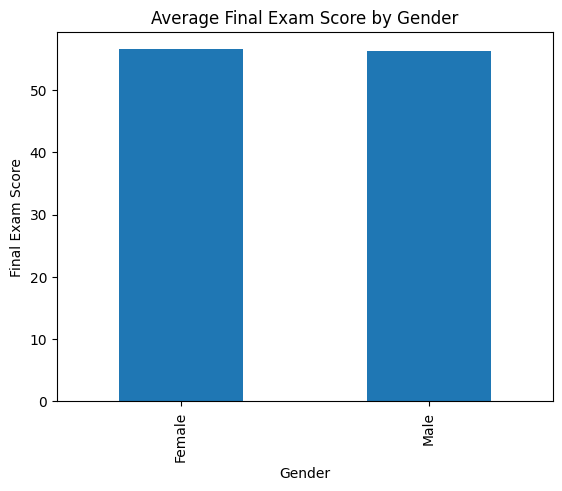

In [ ]:
import matplotlib.pyplot as plt

gender_avg.plot(kind="bar")

plt.title("Average Final Exam Score by Gender")
plt.ylabel("Final Exam Score")

plt.show()

**PIE CHART**

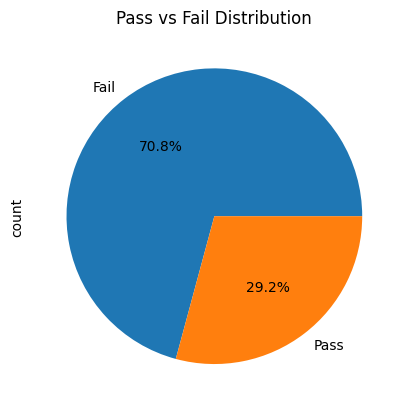

In [ ]:
df["Pass_Fail"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Pass vs Fail Distribution")

plt.show()

**LINE CHART**

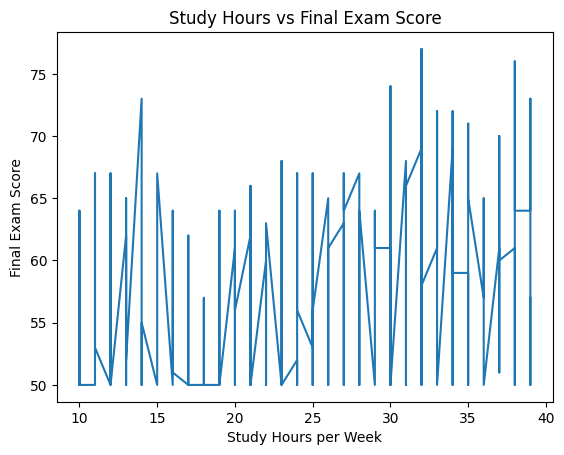

In [ ]:
df_sorted = df.sort_values(
    "Study_Hours_per_Week"
)

plt.plot(
    df_sorted["Study_Hours_per_Week"],
    df_sorted["Final_Exam_Score"]
)

plt.xlabel("Study Hours per Week")
plt.ylabel("Final Exam Score")

plt.title(
    "Study Hours vs Final Exam Score"
)

plt.show()

## Insights

1. Female students achieved a slightly higher average final exam score (56.49) than male students (56.26).

2. Attendance rate showed a moderate positive correlation (0.436) with final exam scores, indicating that students who attend classes regularly tend to perform better.

3. Study hours per week showed a positive correlation (0.375) with final exam scores, suggesting that increased study time generally improves performance.

4. Attendance had a slightly stronger impact on academic performance than study hours.

5. Students whose parents had a Master's degree achieved the highest average final exam score (57.00), though differences across education levels were small.

6. Students participating in extracurricular activities scored slightly higher (56.68) than those who did not participate (56.12).

7. Internet access at home showed minimal impact on academic performance in this dataset.

## Conclusion

This project analyzed student performance using attendance rate, study hours, parental education level, internet access at home, extracurricular activities, and gender. The analysis showed that attendance and study hours positively influence final exam scores, with attendance having a slightly stronger effect. Overall, regular attendance and consistent study habits contribute to improved academic performance.